Please scroll all the way down to the bottom, there are several cells that are just my testing process. The finished product has all these processes combined.

In [2]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/LOL matches.zip'
extraction_dir = '/content/lol_matches_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"'{zip_file_path}' unzipped to '{extraction_dir}' successfully.")

# List the contents of the extracted directory to find the CSV file
print("Contents of extracted directory:")
for item in os.listdir(extraction_dir):
    print(item)


'/content/LOL matches.zip' unzipped to '/content/lol_matches_data' successfully.
Contents of extracted directory:
teambans.csv
stats2.csv
stats1.csv
matches.csv
champs.csv
participants.csv
teamstats.csv


In [3]:
# Assuming the zip file contains a CSV named 'matches.csv' or similar.
# You might need to adjust the filename below based on the output of the previous cell.
csv_file_path = os.path.join(extraction_dir, 'matches.csv') # Common filename, adjust if different

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}' into DataFrame 'df'.")
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())
    print("\nDataFrame Info:")
    display(df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{csv_file_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")


Successfully loaded '/content/lol_matches_data/matches.csv' into DataFrame 'df'.

First 5 rows of the DataFrame:


,id,gameid,platformid,queueid,seasonid,duration,creation,version
0,10,3187427022,EUW1,420,8,1909,1495068946860,7.10.187.9675
1,11,3187425281,EUW1,420,8,1693,1495066760778,7.10.187.9675
2,12,3187269801,EUW1,420,8,1482,1495053375889,7.10.187.9675
3,13,3187252065,EUW1,420,8,1954,1495050993613,7.10.187.9675
4,14,3187201038,EUW1,420,8,2067,1495047893400,7.10.187.9675



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184069 entries, 0 to 184068
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          184069 non-null  int64 
 1   gameid      184069 non-null  int64 
 2   platformid  184069 non-null  object
 3   queueid     184069 non-null  int64 
 4   seasonid    184069 non-null  int64 
 5   duration    184069 non-null  int64 
 6   creation    184069 non-null  int64 
 7   version     184069 non-null  object
dtypes: int64(6), object(2)
memory usage: 11.2+ MB


None

### Load Additional Data: Participants and Stats

To build player-level metrics like `performance_score` and `player_type` for the plots, we need to load `participants.csv` and `stats1.csv`. These files typically contain details about individual players within each match and their in-game statistics.

In [4]:
# Load participants.csv
participants_csv_path = os.path.join(extraction_dir, 'participants.csv')
try:
    participants_df = pd.read_csv(participants_csv_path)
    print(f"Successfully loaded '{participants_csv_path}' into DataFrame 'participants_df'.")
    print("\nFirst 5 rows of participants_df:")
    display(participants_df.head())
    print("\nparticipants_df Info:")
    display(participants_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{participants_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading participants.csv: {e}")

# Load stats1.csv
stats_csv_path = os.path.join(extraction_dir, 'stats1.csv')
try:
    stats_df = pd.read_csv(stats_csv_path)
    print(f"\nSuccessfully loaded '{stats_csv_path}' into DataFrame 'stats_df'.")
    print("\nFirst 5 rows of stats_df:")
    display(stats_df.head())
    print("\nstats_df Info:")
    display(stats_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{stats_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading stats1.csv: {e}")


Successfully loaded '/content/lol_matches_data/participants.csv' into DataFrame 'participants_df'.

First 5 rows of participants_df:


,id,matchid,player,championid,ss1,ss2,role,position
0,9,10,1,19,4,11,NONE,JUNGLE
1,10,10,2,267,3,4,DUO_SUPPORT,BOT
2,11,10,3,119,7,4,DUO_CARRY,BOT
3,12,10,4,114,12,4,SOLO,TOP
4,13,10,5,112,4,3,SOLO,MID



participants_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834520 entries, 0 to 1834519
Data columns (total 8 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   id          int64 
 1   matchid     int64 
 2   player      int64 
 3   championid  int64 
 4   ss1         int64 
 5   ss2         int64 
 6   role        object
 7   position    object
dtypes: int64(6), object(2)
memory usage: 112.0+ MB


None


Successfully loaded '/content/lol_matches_data/stats1.csv' into DataFrame 'stats_df'.

First 5 rows of stats_df:


,id,win,item1,item2,item3,item4,item5,item6,trinket,kills,...,neutralminionskilled,ownjunglekills,enemyjunglekills,totcctimedealt,champlvl,pinksbought,wardsbought,wardsplaced,wardskilled,firstblood
0,9,0,3748,2003,3111,3053,1419,1042,3340,6,...,69,42,27,610,13,0,0,10,0,0
1,10,0,2301,3111,3190,3107,0,0,3364,0,...,1,1,0,211,14,1,0,17,3,0
2,11,0,1055,3072,3006,3031,3046,1036,3340,7,...,3,1,2,182,14,1,0,13,5,0
3,12,0,1029,3078,3156,1001,3053,0,3340,5,...,6,6,0,106,15,0,0,3,0,0
4,13,0,3020,1058,3198,3102,1052,1026,3340,2,...,4,3,1,159,15,0,0,10,0,0



stats_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 56 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   id                      999999 non-null  int64
 1   win                     999999 non-null  int64
 2   item1                   999999 non-null  int64
 3   item2                   999999 non-null  int64
 4   item3                   999999 non-null  int64
 5   item4                   999999 non-null  int64
 6   item5                   999999 non-null  int64
 7   item6                   999999 non-null  int64
 8   trinket                 999999 non-null  int64
 9   kills                   999999 non-null  int64
 10  deaths                  999999 non-null  int64
 11  assists                 999999 non-null  int64
 12  largestkillingspree     999999 non-null  int64
 13  largestmultikill        999999 non-null  int64
 14  killingsprees           999999 non-n

None

### Combine Player Stats and Merge DataFrames

Since we have `stats1.csv` and `stats2.csv`, we should combine them to get a complete set of player statistics. Then, we'll merge this with `participants_df` and `df` (matches data) to create a comprehensive player-level dataset, which is essential for calculating performance and behavior metrics.

In [10]:
# Load stats2.csv
stats2_csv_path = os.path.join(extraction_dir, 'stats2.csv')
try:
    # Specify dtype for 'wardsbought' to avoid mixed types warning, coercing errors
    # Also, tell pandas to interpret '\N' as a NaN value during loading.
    stats2_df = pd.read_csv(stats2_csv_path, dtype={'wardsbought': float}, na_values=['\\N'], low_memory=False)
    print(f"\nSuccessfully loaded '{stats2_csv_path}' into DataFrame 'stats2_df'.")
    print("\nFirst 5 rows of stats2_df:")
    display(stats2_df.head())
    print("\nstats2_df Info:")
    display(stats2_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{stats2_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading stats2.csv: {e}")

# Concatenate stats1_df and stats2_df to create a full stats_df
combined_stats_df = pd.concat([stats_df, stats2_df], ignore_index=True)
print(f"\nCombined stats DataFrame created with {len(combined_stats_df)} entries.")
print("\nCombined stats_df Info:")
display(combined_stats_df.info())


Successfully loaded '/content/lol_matches_data/stats2.csv' into DataFrame 'stats2_df'.

First 5 rows of stats2_df:


,id,win,item1,item2,item3,item4,item5,item6,trinket,kills,...,neutralminionskilled,ownjunglekills,enemyjunglekills,totcctimedealt,champlvl,pinksbought,wardsbought,wardsplaced,wardskilled,firstblood
0,1028382,0,1056,3001,1052,3020,1058,1026,3340,7,...,0,0,0,50,12,0,0.0,6,0,0
1,1028383,0,1041,2003,0,0,0,0,3340,0,...,11,11,0,114,3,0,0.0,0,0,0
2,1028384,0,1036,2010,0,0,0,0,3340,0,...,0,0,0,0,1,0,0.0,0,0,0
3,1028385,0,1055,2010,0,0,0,0,3340,0,...,0,0,0,0,2,0,0.0,0,0,0
4,1028386,0,2033,0,0,0,0,0,3340,0,...,0,0,0,0,3,0,0.0,0,0,0



stats2_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834518 entries, 0 to 834517
Data columns (total 56 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      834518 non-null  int64  
 1   win                     834518 non-null  int64  
 2   item1                   834518 non-null  int64  
 3   item2                   834518 non-null  int64  
 4   item3                   834518 non-null  int64  
 5   item4                   834518 non-null  int64  
 6   item5                   834518 non-null  int64  
 7   item6                   834518 non-null  int64  
 8   trinket                 834518 non-null  int64  
 9   kills                   834518 non-null  int64  
 10  deaths                  834518 non-null  int64  
 11  assists                 834518 non-null  int64  
 12  largestkillingspree     834518 non-null  int64  
 13  largestmultikill        834518 non-null  int64  
 14  kil

None


Combined stats DataFrame created with 1834517 entries.

Combined stats_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834517 entries, 0 to 1834516
Data columns (total 56 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      int64  
 1   win                     int64  
 2   item1                   int64  
 3   item2                   int64  
 4   item3                   int64  
 5   item4                   int64  
 6   item5                   int64  
 7   item6                   int64  
 8   trinket                 int64  
 9   kills                   int64  
 10  deaths                  int64  
 11  assists                 int64  
 12  largestkillingspree     int64  
 13  largestmultikill        int64  
 14  killingsprees           int64  
 15  longesttimespentliving  int64  
 16  doublekills             int64  
 17  triplekills             int64  
 18  quadrakills             int64  
 19  pentakills              

None

In [9]:
# Merge participants_df with combined_stats_df
# The 'id' column in both dataframes refers to the participant ID within a match.
# 'matchid' ensures we link the correct participant stats to the correct match and player entry.
player_data = pd.merge(participants_df, combined_stats_df, on='id', how='inner')
print(f"\nMerged participants and stats into 'player_data' with {len(player_data)} entries.")
print("\nFirst 5 rows of player_data:")
display(player_data.head())
print("\nplayer_data Info:")
display(player_data.info())

# Now, merge 'player_data' with the main 'df' (matches data) to get match duration, etc.
# The common column is 'matchid' from player_data and 'gameid' from df. We should rename 'gameid' in df to 'matchid'.
# Let's check df.head() for column names. It has 'gameid'. player_data has 'matchid'.
# Rename 'gameid' in df to 'matchid' for merging.
df_renamed = df.rename(columns={'gameid': 'matchid'})
full_data_df = pd.merge(player_data, df_renamed[['matchid', 'duration', 'seasonid', 'queueid']], on='matchid', how='left')
print(f"\nMerged all data into 'full_data_df' with {len(full_data_df)} entries.")
print("\nFirst 5 rows of full_data_df:")
display(full_data_df.head())
print("\nfull_data_df Info:")
display(full_data_df.info())


Merged participants and stats into 'player_data' with 1834517 entries.

First 5 rows of player_data:


,id,matchid,player,championid,ss1,ss2,role,position,win,item1,...,neutralminionskilled,ownjunglekills,enemyjunglekills,totcctimedealt,champlvl,pinksbought,wardsbought,wardsplaced,wardskilled,firstblood
0,9,10,1,19,4,11,NONE,JUNGLE,0,3748,...,69,42,27,610,13,0,0,10,0,0
1,10,10,2,267,3,4,DUO_SUPPORT,BOT,0,2301,...,1,1,0,211,14,1,0,17,3,0
2,11,10,3,119,7,4,DUO_CARRY,BOT,0,1055,...,3,1,2,182,14,1,0,13,5,0
3,12,10,4,114,12,4,SOLO,TOP,0,1029,...,6,6,0,106,15,0,0,3,0,0
4,13,10,5,112,4,3,SOLO,MID,0,3020,...,4,3,1,159,15,0,0,10,0,0



player_data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834517 entries, 0 to 1834516
Data columns (total 63 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   id                      int64 
 1   matchid                 int64 
 2   player                  int64 
 3   championid              int64 
 4   ss1                     int64 
 5   ss2                     int64 
 6   role                    object
 7   position                object
 8   win                     int64 
 9   item1                   int64 
 10  item2                   int64 
 11  item3                   int64 
 12  item4                   int64 
 13  item5                   int64 
 14  item6                   int64 
 15  trinket                 int64 
 16  kills                   int64 
 17  deaths                  int64 
 18  assists                 int64 
 19  largestkillingspree     int64 
 20  largestmultikill        int64 
 21  killingsprees           int64 
 22 

None


Merged all data into 'full_data_df' with 1834517 entries.

First 5 rows of full_data_df:


,id,matchid,player,championid,ss1,ss2,role,position,win,item1,...,totcctimedealt,champlvl,pinksbought,wardsbought,wardsplaced,wardskilled,firstblood,duration,seasonid,queueid
0,9,10,1,19,4,11,NONE,JUNGLE,0,3748,...,610,13,0,0,10,0,0,NaN,NaN,NaN
1,10,10,2,267,3,4,DUO_SUPPORT,BOT,0,2301,...,211,14,1,0,17,3,0,NaN,NaN,NaN
2,11,10,3,119,7,4,DUO_CARRY,BOT,0,1055,...,182,14,1,0,13,5,0,NaN,NaN,NaN
3,12,10,4,114,12,4,SOLO,TOP,0,1029,...,106,15,0,0,3,0,0,NaN,NaN,NaN
4,13,10,5,112,4,3,SOLO,MID,0,3020,...,159,15,0,0,10,0,0,NaN,NaN,NaN



full_data_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834517 entries, 0 to 1834516
Data columns (total 66 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      int64  
 1   matchid                 int64  
 2   player                  int64  
 3   championid              int64  
 4   ss1                     int64  
 5   ss2                     int64  
 6   role                    object 
 7   position                object 
 8   win                     int64  
 9   item1                   int64  
 10  item2                   int64  
 11  item3                   int64  
 12  item4                   int64  
 13  item5                   int64  
 14  item6                   int64  
 15  trinket                 int64  
 16  kills                   int64  
 17  deaths                  int64  
 18  assists                 int64  
 19  largestkillingspree     int64  
 20  largestmultikill        int64  
 21  killingspre

None

### Calculate Performance and Behavior Scores, and Categorize Players

To categorize players as 'well performing' or 'well behaving', we first need to define and calculate a `performance_score` and a `behavior_score` for each player. These scores will be derived from various in-game statistics.

**Performance Metrics:** Kills, assists, damage dealt, gold earned, minions killed, win/loss, and KDA (Kills + Assists / Deaths).

**Behavior Metrics:** Wards placed, wards bought, pink wards bought, vision score, and assists (as an indicator of teamwork).

After calculating these scores, we will scale them and then categorize players into four archetypes based on whether their scores are above or below a certain threshold (e.g., the 75th percentile for 'good' performance/behavior).

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Handle NaN values in 'wardsbought' by filling with 0, as NaN likely means 0 wards bought.
# Also convert to numeric type after filling, if there were any non-numeric values remaining.
full_data_df['wardsbought'] = pd.to_numeric(full_data_df['wardsbought'].fillna(0), errors='coerce').fillna(0)

# Calculate KDA (Kills, Deaths, Assists) with handling for zero deaths
# Add 1 to deaths to avoid division by zero and to soften the impact of very low deaths.
full_data_df['kda'] = (full_data_df['kills'] + full_data_df['assists']) / (full_data_df['deaths'] + 1)

# Define metrics for performance and behavior scores
performance_metrics = [
    'kills', 'assists', 'totdmgdealt', 'goldearned', 'totminionskilled', 'kda', 'win'
]

behavior_metrics = [
    'wardsplaced', 'wardsbought', 'pinksbought', 'visionscore', 'assists'
]

# Ensure all metrics are numeric and handle any remaining non-numeric values by coercing to NaN and then filling with 0
for col in performance_metrics + behavior_metrics:
    if col in full_data_df.columns:
        full_data_df[col] = pd.to_numeric(full_data_df[col], errors='coerce').fillna(0)
    else:
        print(f"Warning: Missing column '{col}'. Adding it with zeros.")
        full_data_df[col] = 0 # Add missing columns with 0

scaler = StandardScaler()

# Scale performance metrics and calculate performance score
scaled_performance_features = scaler.fit_transform(full_data_df[performance_metrics])
full_data_df['performance_score'] = scaled_performance_features.mean(axis=1)

# Scale behavior metrics and calculate behavior score
scaled_behavior_features = scaler.fit_transform(full_data_df[behavior_metrics])
full_data_df['behavior_score'] = scaled_behavior_features.mean(axis=1)

# Define player types based on quantiles (e.g., 75th percentile for "good")
# Using median (0.5 quantile) to separate players into roughly equal halves for 'good' vs 'bad'
perf_threshold = full_data_df['performance_score'].median()
beh_threshold = full_data_df['behavior_score'].median()

def categorize_player(row):
    is_good_perf = row['performance_score'] >= perf_threshold
    is_good_beh = row['behavior_score'] >= beh_threshold

    if is_good_perf and is_good_beh:
        return 'Good Perf & Beh'
    elif is_good_perf and not is_good_beh:
        return 'Good Perf, Bad Beh'
    elif not is_good_perf and is_good_beh:
        return 'Bad Perf, Good Beh'
    else:
        return 'Bad Perf & Beh'

full_data_df['player_type'] = full_data_df.apply(categorize_player, axis=1)

print("Player categorization complete. Sample of player_type and scores:")
display(full_data_df[['performance_score', 'behavior_score', 'player_type']].head())

Player categorization complete. Sample of player_type and scores:


,performance_score,behavior_score,player_type
0,-0.595136,-0.438720,Bad Perf & Beh
1,-0.410102,0.444434,"Bad Perf, Good Beh"
2,-0.050072,0.056094,"Bad Perf, Good Beh"
3,-0.377834,-0.693960,Bad Perf & Beh
4,-0.336115,-0.393460,Bad Perf & Beh


### Visualize Performance Distribution by Player Archetype

Now that players are categorized, we can visualize the distribution of `performance_score` across these archetypes using a box plot. This will help us understand how performance varies among 'Good Perf & Beh', 'Good Perf, Bad Beh', 'Bad Perf, Good Beh', and 'Bad Perf & Beh' players.

/tmp/ipykernel_5455/639674882.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='player_type', y='performance_score', data=full_data_df,
/tmp/ipykernel_5455/639674882.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


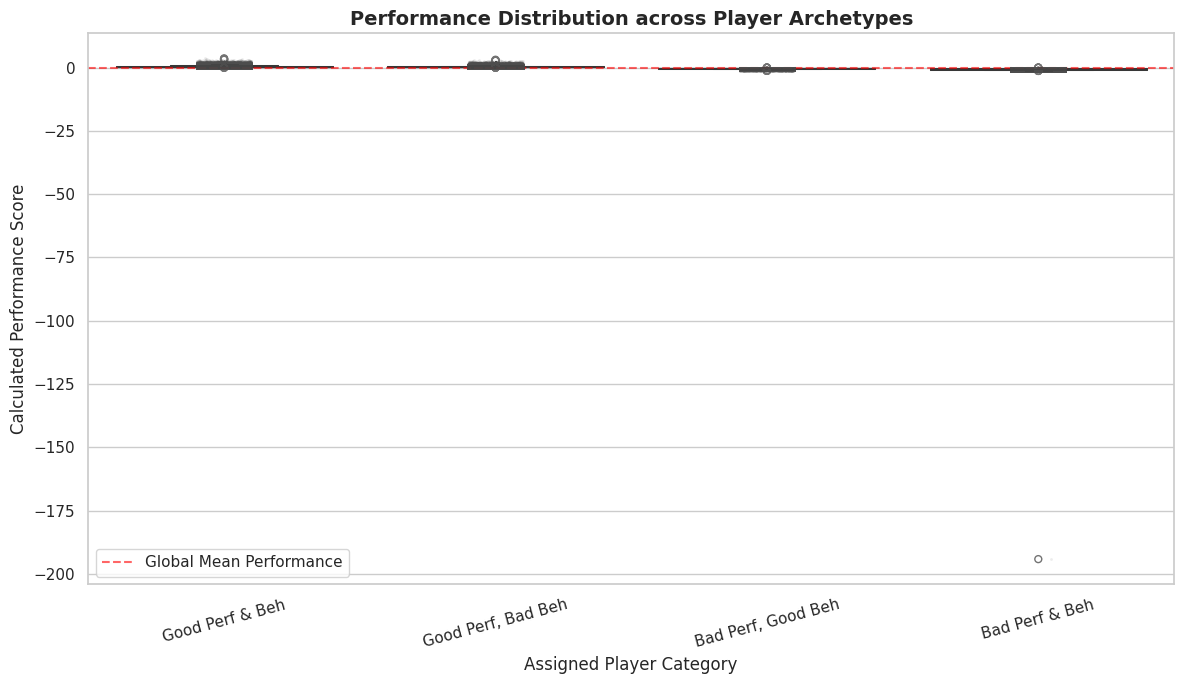

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(12, 7))

# Define labels for clarity in the desired order for plotting
labels_order = ['Good Perf & Beh', 'Good Perf, Bad Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh']

# Using 'boxenplot' (Letter-value plot) which is suitable for large datasets
sns.boxenplot(x='player_type', y='performance_score', data=full_data_df,
              palette='viridis', order=labels_order)

# Use 'stripplot' with high alpha (transparency) for density visualization, adding jitter to avoid overlap
sns.stripplot(x='player_type', y='performance_score', data=full_data_df,
              color='0.3', size=2, alpha=0.1, jitter=True, order=labels_order)

plt.title('Performance Distribution across Player Archetypes', fontsize=14, weight='bold')
plt.xlabel('Assigned Player Category', fontsize=12)
plt.ylabel('Calculated Performance Score', fontsize=12)
plt.xticks(rotation=15) # Rotate x-axis labels if they overlap

# Add a horizontal line for the mean performance across all players
plt.axhline(full_data_df['performance_score'].mean(), color='red', linestyle='--', alpha=0.6, label='Global Mean Performance')
plt.legend()

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

/tmp/ipykernel_5455/549917573.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='player_type', y='behavior_score', data=full_data_df,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


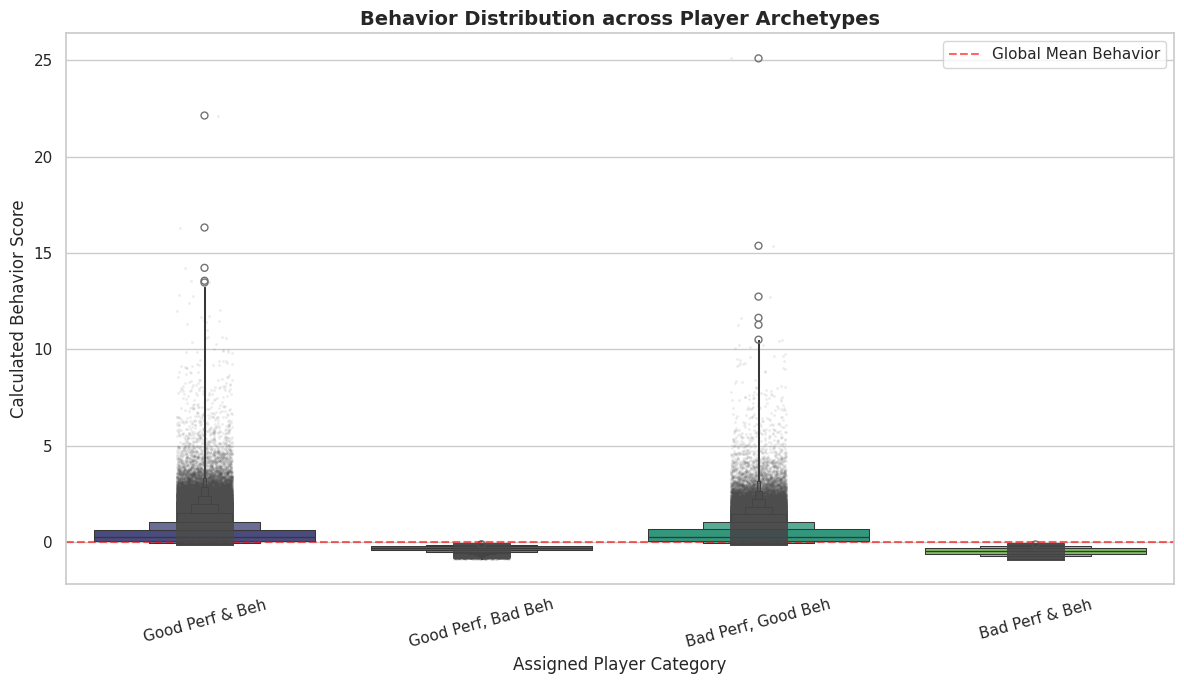

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(12, 7))

# Define labels for clarity in the desired order for plotting
labels_order = ['Good Perf & Beh', 'Good Perf, Bad Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh']

# Using 'boxenplot' for behavior score distribution
sns.boxenplot(x='player_type', y='behavior_score', data=full_data_df,
              palette='viridis', order=labels_order)

# Add stripplot for density visualization with jitter
sns.stripplot(x='player_type', y='behavior_score', data=full_data_df,
              color='0.3', size=2, alpha=0.1, jitter=True, order=labels_order)

plt.title('Behavior Distribution across Player Archetypes', fontsize=14, weight='bold')
plt.xlabel('Assigned Player Category', fontsize=12)
plt.ylabel('Calculated Behavior Score', fontsize=12)
plt.xticks(rotation=15)

# Add a horizontal line for the mean behavior across all players
plt.axhline(full_data_df['behavior_score'].mean(), color='red', linestyle='--', alpha=0.6, label='Global Mean Behavior')
plt.legend()

plt.tight_layout()
plt.show()

'/content/LOL matches.zip' unzipped to '/content/lol_matches_data' successfully.
Contents of extracted directory:
teambans.csv
stats2.csv
stats1.csv
matches.csv
champs.csv
participants.csv
teamstats.csv
Successfully loaded '/content/lol_matches_data/matches.csv' into DataFrame 'df'.

First 5 rows of the DataFrame:


,id,gameid,platformid,queueid,seasonid,duration,creation,version
0,10,3187427022,EUW1,420,8,1909,1495068946860,7.10.187.9675
1,11,3187425281,EUW1,420,8,1693,1495066760778,7.10.187.9675
2,12,3187269801,EUW1,420,8,1482,1495053375889,7.10.187.9675
3,13,3187252065,EUW1,420,8,1954,1495050993613,7.10.187.9675
4,14,3187201038,EUW1,420,8,2067,1495047893400,7.10.187.9675



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184069 entries, 0 to 184068
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          184069 non-null  int64 
 1   gameid      184069 non-null  int64 
 2   platformid  184069 non-null  object
 3   queueid     184069 non-null  int64 
 4   seasonid    184069 non-null  int64 
 5   duration    184069 non-null  int64 
 6   creation    184069 non-null  int64 
 7   version     184069 non-null  object
dtypes: int64(6), object(2)
memory usage: 11.2+ MB


None

Successfully loaded '/content/lol_matches_data/participants.csv' into DataFrame 'participants_df'.

First 5 rows of participants_df:


...


full_data_df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1834517 entries, 0 to 1834516
Data columns (total 66 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      int64  
 1   matchid                 int64  
 2   player                  int64  
 3   championid              int64  
 4   ss1                     int64  
 5   ss2                     int64  
 6   role                    object 
 7   position                object 
 8   win                     int64  
 9   item1                   int64  
 10  item2                   int64  
 11  item3                   int64  
 12  item4                   int64  
 13  item5                   int64  
 14  item6                   int64  
 15  trinket                 int64  
 16  kills                   int64  
 17  deaths                  int64  
 18  assists                 int64  
 19  largestkillingspree     int64  
 20  largestmultikill        int64  
 21  killingspre

None

Player categorization complete. Sample of player_type and scores:


,performance_score,behavior_score,player_type
0,-0.595136,-0.438720,Bad Perf & Beh
1,-0.410102,0.444434,"Bad Perf, Good Beh"
2,-0.050072,0.056094,"Bad Perf, Good Beh"
3,-0.377834,-0.693960,Bad Perf & Beh
4,-0.336115,-0.393460,Bad Perf & Beh


/tmp/ipykernel_8779/1373905379.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='player_type', y='performance_score', data=full_data_df,
/tmp/ipykernel_8779/1373905379.py:200: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


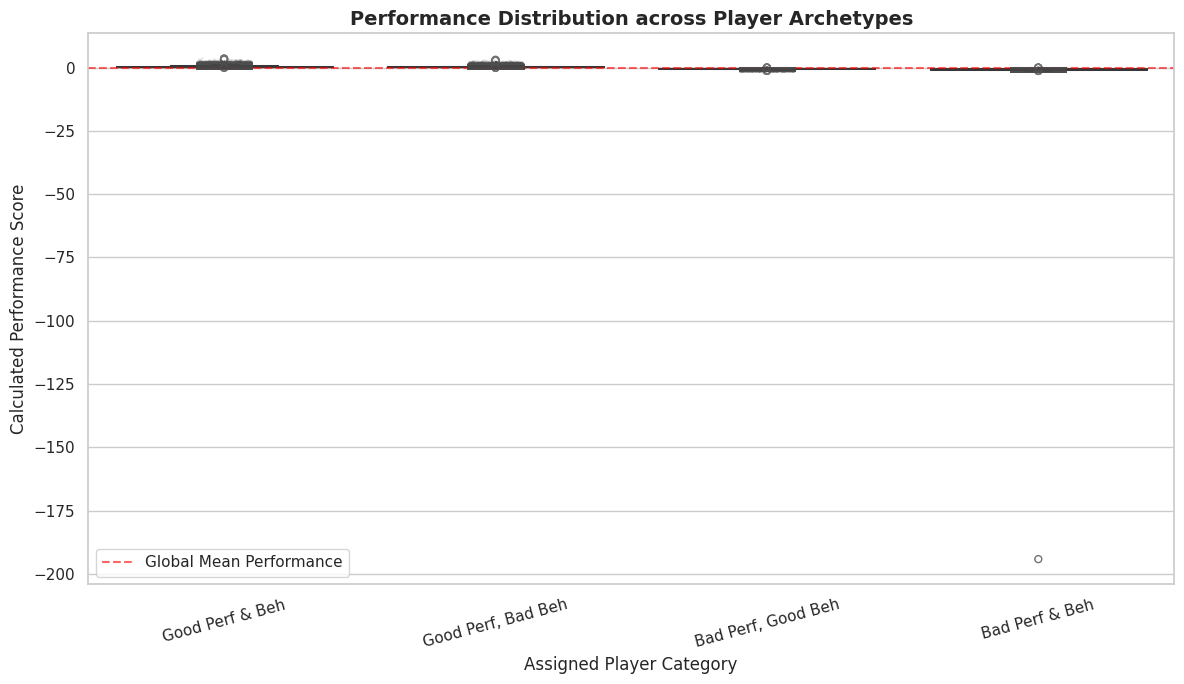

/tmp/ipykernel_8779/1373905379.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='player_type', y='behavior_score', data=full_data_df,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


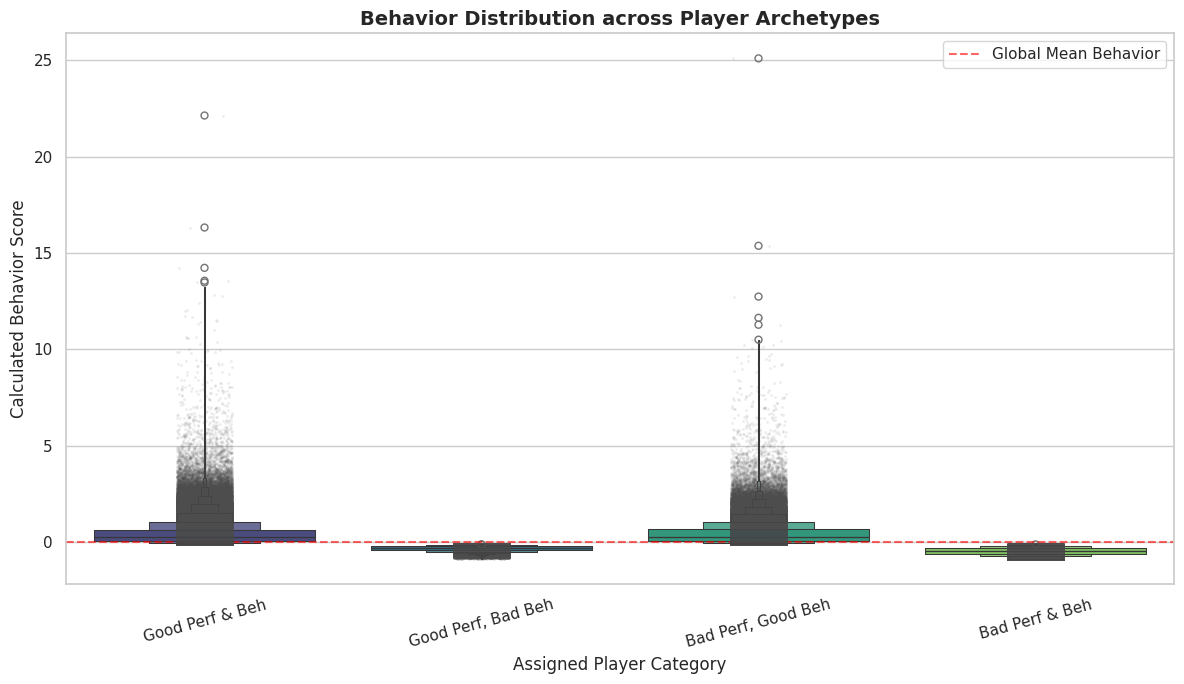

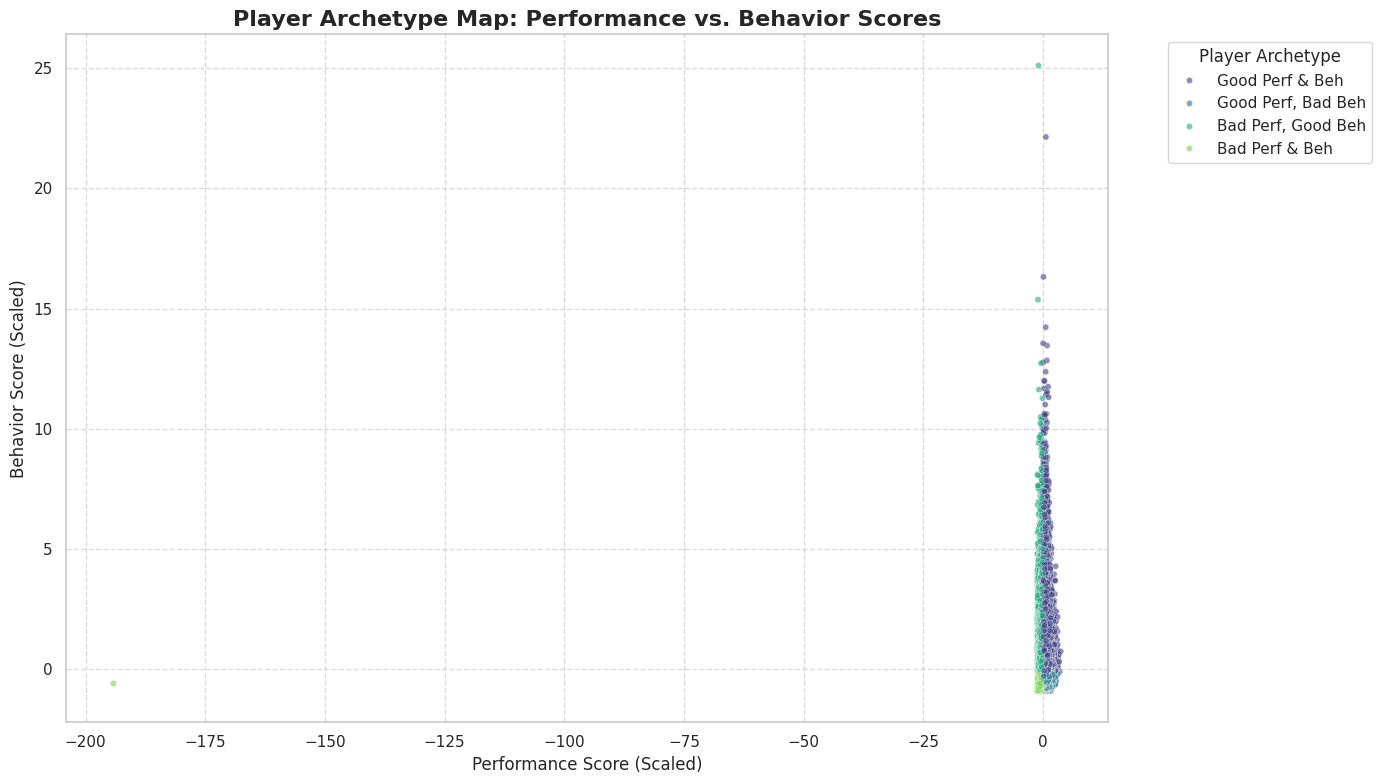

In [1]:
import zipfile
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/LOL matches.zip'
extraction_dir = '/content/lol_matches_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"'{zip_file_path}' unzipped to '{extraction_dir}' successfully.")

# List the contents of the extracted directory to find the CSV file
print("Contents of extracted directory:")
for item in os.listdir(extraction_dir):
    print(item)

# Assuming the zip file contains a CSV named 'matches.csv' or similar.
# You might need to adjust the filename below based on the output of the previous cell.
csv_file_path = os.path.join(extraction_dir, 'matches.csv') # Common filename, adjust if different

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_file_path}' into DataFrame 'df'.")
    print("\nFirst 5 rows of the DataFrame:")
    display(df.head())
    print("\nDataFrame Info:")
    display(df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{csv_file_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

# Load participants.csv
participants_csv_path = os.path.join(extraction_dir, 'participants.csv')
try:
    participants_df = pd.read_csv(participants_csv_path)
    print(f"Successfully loaded '{participants_csv_path}' into DataFrame 'participants_df'.")
    print("\nFirst 5 rows of participants_df:")
    display(participants_df.head())
    print("\nparticipants_df Info:")
    display(participants_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{participants_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading participants.csv: {e}")

# Load stats1.csv
stats_csv_path = os.path.join(extraction_dir, 'stats1.csv')
try:
    stats_df = pd.read_csv(stats_csv_path)
    print(f"\nSuccessfully loaded '{stats_csv_path}' into DataFrame 'stats_df'.")
    print("\nFirst 5 rows of stats_df:")
    display(stats_df.head())
    print("\nstats_df Info:")
    display(stats_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{stats_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading stats1.csv: {e}")

# Load stats2.csv
stats2_csv_path = os.path.join(extraction_dir, 'stats2.csv')
try:
    # Specify dtype for 'wardsbought' to avoid mixed types warning, coercing errors
    # Also, tell pandas to interpret '\N' as a NaN value during loading.
    stats2_df = pd.read_csv(stats2_csv_path, dtype={'wardsbought': float}, na_values=['\\N'], low_memory=False)
    print(f"\nSuccessfully loaded '{stats2_csv_path}' into DataFrame 'stats2_df'.")
    print("\nFirst 5 rows of stats2_df:")
    display(stats2_df.head())
    print("\nstats2_df Info:")
    display(stats2_df.info())
except FileNotFoundError:
    print(f"Error: CSV file not found at '{stats2_csv_path}'. Please check the filename and path.")
except Exception as e:
    print(f"An error occurred while loading stats2.csv: {e}")

# Concatenate stats1_df and stats2_df to create a full stats_df
combined_stats_df = pd.concat([stats_df, stats2_df], ignore_index=True)
print(f"\nCombined stats DataFrame created with {len(combined_stats_df)} entries.")
print("\nCombined stats_df Info:")
display(combined_stats_df.info())

# Merge participants_df with combined_stats_df
# The 'id' column in both dataframes refers to the participant ID within a match.
# 'matchid' ensures we link the correct participant stats to the correct match and player entry.
player_data = pd.merge(participants_df, combined_stats_df, on='id', how='inner')
print(f"\nMerged participants and stats into 'player_data' with {len(player_data)} entries.")
print("\nFirst 5 rows of player_data:")
display(player_data.head())
print("\nplayer_data Info:")
display(player_data.info())

# Now, merge 'player_data' with the main 'df' (matches data) to get match duration, etc.
# The common column is 'matchid' from player_data and 'gameid' from df. We should rename 'gameid' in df to 'matchid'.
# Let's check df.head() for column names. It has 'gameid'. player_data has 'matchid'.
# Rename 'gameid' in df to 'matchid' for merging.
df_renamed = df.rename(columns={'gameid': 'matchid'})
full_data_df = pd.merge(player_data, df_renamed[['matchid', 'duration', 'seasonid', 'queueid']], on='matchid', how='left')
print(f"\nMerged all data into 'full_data_df' with {len(full_data_df)} entries.")
print("\nFirst 5 rows of full_data_df:")
display(full_data_df.head())
print("\nfull_data_df Info:")
display(full_data_df.info())

# Handle NaN values in 'wardsbought' by filling with 0, as NaN likely means 0 wards bought.
# Also convert to numeric type after filling, if there were any non-numeric values remaining.
full_data_df['wardsbought'] = pd.to_numeric(full_data_df['wardsbought'].fillna(0), errors='coerce').fillna(0)

# Calculate KDA (Kills, Deaths, Assists) with handling for zero deaths
# Add 1 to deaths to avoid division by zero and to soften the impact of very low deaths.
full_data_df['kda'] = (full_data_df['kills'] + full_data_df['assists']) / (full_data_df['deaths'] + 1)

# Define metrics for performance and behavior scores
performance_metrics = [
    'kills', 'assists', 'totdmgdealt', 'goldearned', 'totminionskilled', 'kda', 'win'
]

behavior_metrics = [
    'wardsplaced', 'wardsbought', 'pinksbought', 'visionscore', 'assists'
]

# Ensure all metrics are numeric and handle any remaining non-numeric values by coercing to NaN and then filling with 0
for col in performance_metrics + behavior_metrics:
    if col in full_data_df.columns:
        full_data_df[col] = pd.to_numeric(full_data_df[col], errors='coerce').fillna(0)
    else:
        print(f"Warning: Missing column '{col}'. Adding it with zeros.")
        full_data_df[col] = 0 # Add missing columns with 0

scaler = StandardScaler()

# Scale performance metrics and calculate performance score
scaled_performance_features = scaler.fit_transform(full_data_df[performance_metrics])
full_data_df['performance_score'] = scaled_performance_features.mean(axis=1)

# Scale behavior metrics and calculate behavior score
scaled_behavior_features = scaler.fit_transform(full_data_df[behavior_metrics])
full_data_df['behavior_score'] = scaled_behavior_features.mean(axis=1)

# Define player types based on quantiles (e.g., 75th percentile for "good")
# Using median (0.5 quantile) to separate players into roughly equal halves for 'good' vs 'bad'
perf_threshold = full_data_df['performance_score'].median()
beh_threshold = full_data_df['behavior_score'].median()

def categorize_player(row):
    is_good_perf = row['performance_score'] >= perf_threshold
    is_good_beh = row['behavior_score'] >= beh_threshold

    if is_good_perf and is_good_beh:
        return 'Good Perf & Beh'
    elif is_good_perf and not is_good_beh:
        return 'Good Perf, Bad Beh'
    elif not is_good_perf and is_good_beh:
        return 'Bad Perf, Good Beh'
    else:
        return 'Bad Perf & Beh'

full_data_df['player_type'] = full_data_df.apply(categorize_player, axis=1)

print("Player categorization complete. Sample of player_type and scores:")
display(full_data_df[['performance_score', 'behavior_score', 'player_type']].head())

# Set a professional, clean aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

plt.figure(figsize=(12, 7))

# Define labels for clarity in the desired order for plotting
labels_order = ['Good Perf & Beh', 'Good Perf, Bad Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh']

# Using 'boxenplot' (Letter-value plot) which is suitable for large datasets
sns.boxenplot(x='player_type', y='performance_score', data=full_data_df,
              palette='viridis', order=labels_order)

# Use 'stripplot' with high alpha (transparency) for density visualization, adding jitter to avoid overlap
sns.stripplot(x='player_type', y='performance_score', data=full_data_df,
              color='0.3', size=2, alpha=0.1, jitter=True, order=labels_order)

plt.title('Performance Distribution across Player Archetypes', fontsize=14, weight='bold')
plt.xlabel('Assigned Player Category', fontsize=12)
plt.ylabel('Calculated Performance Score', fontsize=12)
plt.xticks(rotation=15) # Rotate x-axis labels if they overlap

# Add a horizontal line for the mean performance across all players
plt.axhline(full_data_df['performance_score'].mean(), color='red', linestyle='--', alpha=0.6, label='Global Mean Performance')
plt.legend()

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

plt.figure(figsize=(12, 7))

# Define labels for clarity in the desired order for plotting
labels_order = ['Good Perf & Beh', 'Good Perf, Bad Beh', 'Bad Perf, Good Beh', 'Bad Perf & Beh']

# Using 'boxenplot' for behavior score distribution
sns.boxenplot(x='player_type', y='behavior_score', data=full_data_df,
              palette='viridis', order=labels_order)

# Add stripplot for density visualization with jitter
sns.stripplot(x='player_type', y='behavior_score', data=full_data_df,
              color='0.3', size=2, alpha=0.1, jitter=True, order=labels_order)

plt.title('Behavior Distribution across Player Archetypes', fontsize=14, weight='bold')
plt.xlabel('Assigned Player Category', fontsize=12)
plt.ylabel('Calculated Behavior Score', fontsize=12)
plt.xticks(rotation=15)

# Add a horizontal line for the mean behavior across all players
plt.axhline(full_data_df['behavior_score'].mean(), color='red', linestyle='--', alpha=0.6, label='Global Mean Behavior')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.scatterplot(x='performance_score', y='behavior_score', hue='player_type', data=full_data_df,
                palette='viridis', alpha=0.6, s=20, hue_order=labels_order)

plt.title('Player Archetype Map: Performance vs. Behavior Scores', fontsize=16, weight='bold')
plt.xlabel('Performance Score (Scaled)', fontsize=12)
plt.ylabel('Behavior Score (Scaled)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Player Archetype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()